Research Question: How do YouTube video categories differ in views, likes, and comments among popular videos in the United States?

## Key Variables

1. **Video Category** - The category assigned to each YouTube video.
2. **Views** - The number of times each video has been viewed.
3. **Likes** - The number of users who have liked each video.
4. **Comments** - The number of comments on each video.
5. **Published Date** - The date and time when each video was published.

# YouTube Video Analysis

## Research Question

How do YouTube video categories differ in views, likes, and comments among popular videos in the United States?

## Key Variables

1. Video Category
2. Views
3. Likes
4. Comments
5. Published Date

## Data Source

The dataset will be collected using the YouTube Data API v3. The API provides information about YouTube videos, including video category, views, likes, comments, and published date. The analysis will focus on popular videos in the United States.

In [1]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

# Load the API key from the .env file
load_dotenv()

API_KEY = os.getenv("YOUTUBE_API_KEY")

# YouTube Data API endpoint
url = "https://www.googleapis.com/youtube/v3/videos"

params = {
    "part": "snippet,statistics",
    "chart": "mostPopular",
    "regionCode": "US",
    "maxResults": 50,
    "key": API_KEY
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)

if response.status_code == 200:
    data = response.json()
    print("Videos collected:", len(data["items"]))
else:
    print("Error:", response.text)

Status Code: 200
Videos collected: 50


In [2]:
# Extract the five variables from the API response

rows = []

for video in data["items"]:
    rows.append({
        "Video Category": video["snippet"].get("categoryId"),
        "Views": video["statistics"].get("viewCount"),
        "Likes": video["statistics"].get("likeCount"),
        "Comments": video["statistics"].get("commentCount"),
        "Published Date": video["snippet"].get("publishedAt")
    })

df = pd.DataFrame(rows)

# Convert numeric variables to numbers
df["Views"] = pd.to_numeric(df["Views"], errors="coerce")
df["Likes"] = pd.to_numeric(df["Likes"], errors="coerce")
df["Comments"] = pd.to_numeric(df["Comments"], errors="coerce")

# Convert published date to datetime
df["Published Date"] = pd.to_datetime(df["Published Date"], errors="coerce")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50, 5)


,Video Category,Views,Likes,Comments,Published Date
0,10,5852802,365006,20405,2026-09-14 17:00:05+00:00
1,1,1310568,24333,1422,2026-09-16 13:00:01+00:00
2,20,205057,30672,1493,2026-09-16 19:13:24+00:00
3,10,111214,2234,139,2026-09-09 07:00:06+00:00
4,1,8454,40564,3100,2026-09-16 18:30:48+00:00


In [3]:
# Inspect the dataset

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (50, 5)

Data types:
Video Category                    str
Views                           int64
Likes                           int64
Comments                        int64
Published Date    datetime64[us, UTC]
dtype: object

Missing values:
Video Category    0
Views             0
Likes             0
Comments          0
Published Date    0
dtype: int64

Duplicate rows: 0


# Get the names of the YouTube video categories

In [14]:
# Get the names of the YouTube video categories

category_url = "https://www.googleapis.com/youtube/v3/videoCategories"

category_params = {
    "part": "snippet",
    "id": ",".join(df["Video Category"].dropna().astype(str).unique()),
    "key": API_KEY
}

category_response = requests.get(category_url, params=category_params)

print("Category Status Code:", category_response.status_code)

if category_response.status_code == 200:
    category_data = category_response.json()

    category_map = {
        item["id"]: item["snippet"]["title"]
        for item in category_data["items"]
    }

    df["Video Category"] = (
        df["Video Category"]
        .astype(str)
        .map(category_map)
    )

    print("Category names added successfully.")
else:
    print("Error:", category_response.text)

df.head()

Category Status Code: 200
Category names added successfully.


,Video Category,Views,Likes,Comments,Published Date
0,NaN,5852802,365006,20405,2026-09-14 17:00:05+00:00
1,NaN,1310568,24333,1422,2026-09-16 13:00:01+00:00
2,NaN,205057,30672,1493,2026-09-16 19:13:24+00:00
3,NaN,111214,2234,139,2026-09-09 07:00:06+00:00
4,NaN,8454,40564,3100,2026-09-16 18:30:48+00:00


## Data Cleaning and Preparation

The dataset was checked for missing values, duplicate rows, and appropriate data types. No missing values or duplicate rows were found. The views, likes, and comments variables were converted to numeric values, while the published date was converted to a datetime format. Video category IDs were also converted into category names using the YouTube Data API. Because the dataset contained no missing or duplicate records, no rows needed to be removed.

In [15]:
# Final data cleaning checks

df = df.drop_duplicates()

df["Views"] = pd.to_numeric(df["Views"], errors="coerce")
df["Likes"] = pd.to_numeric(df["Likes"], errors="coerce")
df["Comments"] = pd.to_numeric(df["Comments"], errors="coerce")
df["Published Date"] = pd.to_datetime(df["Published Date"], errors="coerce")

print("Final dataset shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Final dataset shape: (50, 5)

Missing values after cleaning:
Video Category    50
Views              0
Likes              0
Comments           0
Published Date     0
dtype: int64

Duplicate rows after cleaning: 0


In [16]:
# Explore the distribution of videos by category

category_counts = df["Video Category"].value_counts()

print("Number of videos in each category:")
print(category_counts)

print("\nAverage engagement by category:")
category_summary = (
    df.groupby("Video Category")[["Views", "Likes", "Comments"]]
    .mean()
    .sort_values("Views", ascending=False)
)

category_summary

Number of videos in each category:
Series([], Name: count, dtype: int64)

Average engagement by category:


,Views,Likes,Comments
Video Category,,,


IndexError: index 0 is out of bounds for axis 0 with size 0

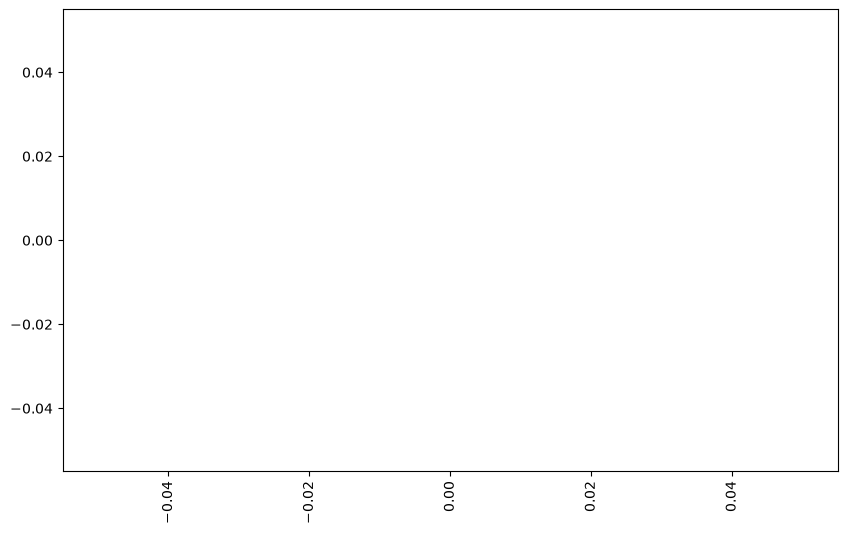

In [17]:
import matplotlib.pyplot as plt

# Count videos in each category
category_counts = df["Video Category"].value_counts()

# Create the bar chart
plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar")

plt.title("Number of Popular YouTube Videos by Category")
plt.xlabel("Video Category")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

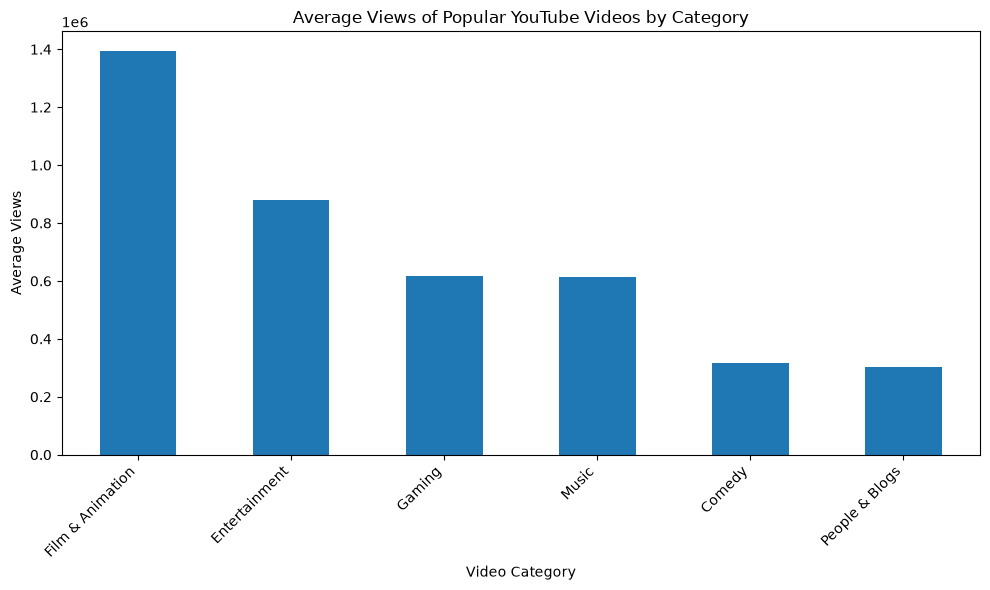

In [ ]:
# Compare average views by video category

average_views = (
    df.groupby("Video Category")["Views"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
average_views.plot(kind="bar")

plt.title("Average Views of Popular YouTube Videos by Category")
plt.xlabel("Video Category")
plt.ylabel("Average Views")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Visualizations and Insights

### Visualization 1: Number of Popular Videos by Category

The first visualization shows how the 50 popular YouTube videos in the dataset are distributed across categories. Gaming had the largest number of videos with 18, followed by Music with 15 and Film & Animation with 8. Entertainment had 6 videos, while People & Blogs and Comedy had 2 and 1 video respectively. This shows that the dataset is not evenly distributed across categories, which is important when interpreting the comparisons.

### Visualization 2: Average Views by Category

The second visualization compares the average number of views across video categories. Film & Animation had the highest average views in this dataset, followed by Entertainment. Gaming and Music had similar average view levels, while Comedy and People & Blogs had lower averages. These results show that the number of views varies across categories among the popular videos collected from the YouTube Data API.

In [ ]:
# Compare average likes and comments by video category

engagement_summary = (
    df.groupby("Video Category")[["Likes", "Comments"]]
    .mean()
    .sort_values("Likes", ascending=False)
)

engagement_summary

,Likes,Comments
Video Category,,
Music,37024.933333,2100.066667
Gaming,27185.944444,3247.000000
Film & Animation,26405.875000,1754.625000
People & Blogs,14784.500000,1075.500000
Entertainment,7150.833333,634.333333
Comedy,5847.000000,388.000000


### Engagement Insights: Likes and Comments

The engagement results show differences across categories. Music had the highest average number of likes at approximately 37,025 likes per video. Gaming had the second-highest average likes at approximately 27,186. Gaming also had the highest average number of comments at approximately 3,247 comments per video, while Music had approximately 2,101 comments per video. These results suggest that different categories can show different patterns across views, likes, and comments.

Because the number of videos differs substantially across categories, these averages should be interpreted carefully. For example, Comedy had only one video in the dataset, while Gaming had 18 videos. Therefore, the category averages describe this particular sample of 50 popular videos and should not be treated as representative of all YouTube videos.

## Limitations, Ethics, and Reflection

This analysis has several limitations. First, the dataset contains only 50 popular YouTube videos collected from the YouTube Data API for the United States, so the results should not be generalized to all YouTube videos. The dataset is also not evenly distributed across categories. Gaming has 18 videos, while Comedy has only 1 video, which can make category averages less stable for categories with fewer observations.

Another limitation is that views, likes, and comments are measures of engagement, but they do not explain why a video received that level of engagement. Factors such as channel size, video length, audience demographics, recommendations, trends, and publication timing are not included in the five variables used in this analysis.

There are also ethical considerations when analyzing platform data. The analysis focuses on aggregate video-level statistics rather than identifying or evaluating individual users. The results should not be used to make assumptions about individual viewers or creators. In addition, the API data represents a particular point in time, so the engagement counts can change after the data is collected.

Finally, this project helped me understand the importance of clearly defining variables, checking data quality, and being careful about what conclusions can be made from a limited dataset. The analysis describes patterns in the collected data rather than establishing cause-and-effect relationships.

## References

Hussain, K., Nusair, K., Junaid, M., & Aman, W. (2024). A two-actor model for understanding user engagement with content creators: Applying social capital theory. *Computers in Human Behavior, 156*, 108237. https://doi.org/10.1016/j.chb.2024.108237

Khan, M. L. (2017). Social media engagement: What motivates user participation and consumption on YouTube? *Computers in Human Behavior, 66*, 236–247. https://doi.org/10.1016/j.chb.2016.09.024

Liikkanen, L. A., & Salovaara, A. (2015). Music on YouTube: User engagement with traditional, user-appropriated and derivative videos. *Computers in Human Behavior, 50*, 108–124. https://doi.org/10.1016/j.chb.2015.01.067


Google for Developers. (n.d.). *YouTube Data API*. https://developers.google.com/youtube/v3

## Storytelling/Narrative

This analysis examined how YouTube video categories differ in views, likes, and comments among 50 popular videos in the United States. The results show that the categories were not evenly represented. Gaming had the largest number of videos in the dataset, followed by Music, while Comedy and People & Blogs had fewer observations.

The engagement measures also varied across categories. Film & Animation had the highest average number of views in this dataset, while Music had the highest average number of likes. Gaming had the highest average number of comments. These results show that views, likes, and comments do not necessarily follow the same pattern across video categories.

Overall, the analysis provides a descriptive snapshot of popular videos returned by the YouTube Data API at the time of collection. The results do not establish that video category causes differences in views, likes, or comments. Other factors, such as channel size, audience, video length, recommendations, trends, and publication timing, may also influence engagement. Therefore, the findings should be interpreted as patterns within this 50-video dataset rather than as a general description of all YouTube content.

## Data Description and Variable Definitions

### Data Source

The data was collected using the YouTube Data API v3. The API was used to retrieve popular YouTube videos for the United States. The `mostPopular` chart was used to collect videos that were popular in the selected region at the time of collection.

### Unit of Analysis

Each row represents one popular YouTube video returned by the API.

### Dataset Size

The final dataset contains 50 videos and 5 research variables. After data cleaning, there were 0 missing values and 0 duplicate rows.

### Conceptualization and Operationalization

**Video Category**
- Conceptual definition: The category assigned to a YouTube video based on its content.
- Operational definition: The video's YouTube category ID was retrieved from the API and converted into a category name using the YouTube Data API.

**Views**
- Conceptual definition: The number of times a video has been viewed.
- Operational definition: The `viewCount` value provided by the YouTube Data API.

**Likes**
- Conceptual definition: The number of users who indicated that they liked a video.
- Operational definition: The `likeCount` value provided by the YouTube Data API.

**Comments**
- Conceptual definition: The number of comments associated with a video.
- Operational definition: The `commentCount` value provided by the YouTube Data API.

**Published Date**
- Conceptual definition: The date and time when a video was published.
- Operational definition: The `publishedAt` value provided by the YouTube Data API, converted to a pandas datetime format.

### Collection Assumptions

The analysis assumes that the 50 videos returned by the API provide a useful snapshot of popular YouTube content in the United States at the time the data was collected. Because the API returns a limited set of popular videos, the dataset is not assumed to represent all YouTube videos or all categories equally.

## Code and AI Transparency

The data was collected using the YouTube Data API v3 and analyzed in Python using pandas and matplotlib. The underlying analysis code is contained in the Jupyter Notebook for this project.

Generative AI was used as an assistance tool during the development of this project. ChatGPT (GPT-5.6 Luna) was used to help brainstorm and refine the research question, explain YouTube Data API documentation, suggest Python code structure, troubleshoot coding issues, and help organize written explanations. The student ran the code in the notebook and checked the resulting outputs.

AI-generated suggestions were not treated as evidence. Information about the YouTube Data API was checked against official Google for Developers documentation, and the academic sources were checked against journal or publisher records. The final analysis, data cleaning decisions, visualizations, and interpretations are presented in the project notebook.

In [18]:
df.to_csv("youtube_video_data.csv", index=False)

print("Dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))


Dataset saved successfully.
Rows: 50
Columns: 5


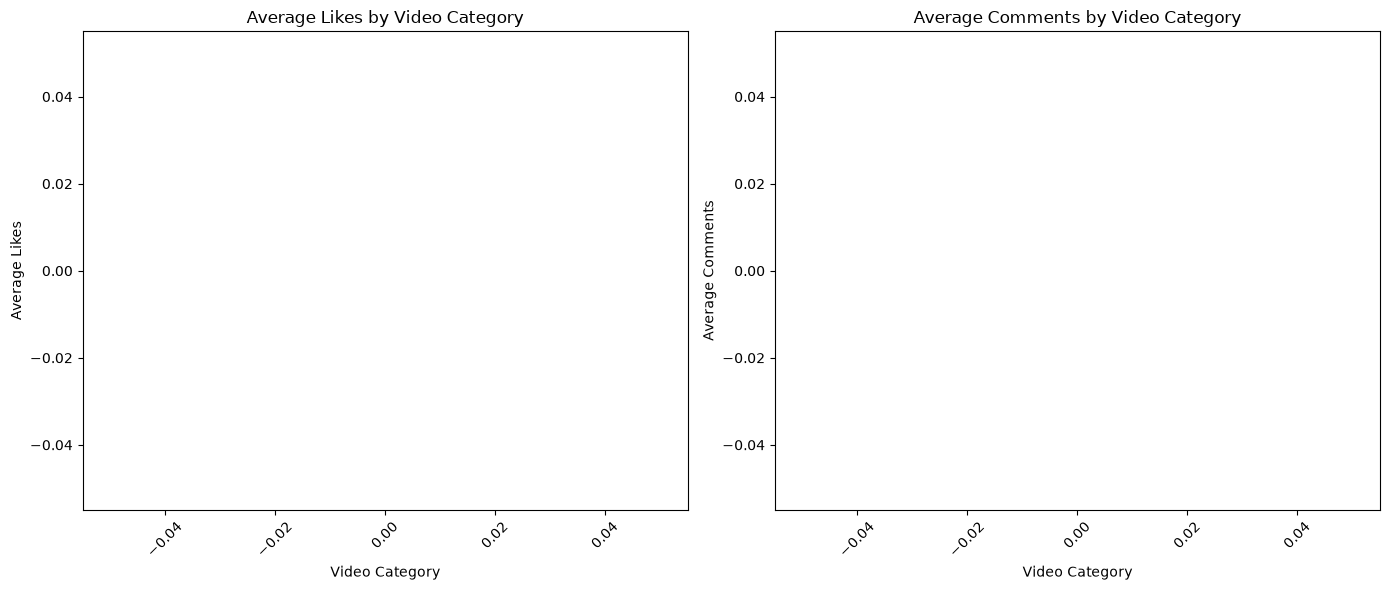

In [22]:
# Compare average likes and comments across video categories

engagement_summary = (
    df.groupby("Video Category")[["Likes", "Comments"]]
    .mean()
    .sort_values("Likes", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average Likes
axes[0].bar(
    engagement_summary.index,
    engagement_summary["Likes"]
)

axes[0].set_title("Average Likes by Video Category")
axes[0].set_xlabel("Video Category")
axes[0].set_ylabel("Average Likes")
axes[0].tick_params(axis="x", rotation=45)

# Average Comments
axes[1].bar(
    engagement_summary.index,
    engagement_summary["Comments"]
)

axes[1].set_title("Average Comments by Video Category")
axes[1].set_xlabel("Video Category")
axes[1].set_ylabel("Average Comments")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [23]:
print("Dataset shape:", df.shape)
print("\nVideo categories:")
print(df["Video Category"].value_counts(dropna=False))

print("\nEngagement summary:")
print(engagement_summary)

Dataset shape: (50, 5)

Video categories:
Video Category
NaN    50
Name: count, dtype: int64

Engagement summary:
Empty DataFrame
Columns: [Likes, Comments]
Index: []


In [25]:
# Restore the original YouTube category IDs from the API response

df["Video Category"] = [
    video["snippet"].get("categoryId")
    for video in data["items"]
]

# Get the category names from the YouTube API
category_url = "https://www.googleapis.com/youtube/v3/videoCategories"

category_params = {
    "part": "snippet",
    "id": ",".join(df["Video Category"].dropna().astype(str).unique()),
    "key": API_KEY
}

category_response = requests.get(category_url, params=category_params)

print("Category Status Code:", category_response.status_code)

if category_response.status_code == 200:
    category_data = category_response.json()

    category_map = {
        item["id"]: item["snippet"]["title"]
        for item in category_data["items"]
    }

    df["Video Category"] = df["Video Category"].map(category_map)

    print("Category names restored successfully.")
    print("\nCategory counts:")
    print(df["Video Category"].value_counts())
else:
    print("Error:", category_response.text)

Category Status Code: 200
Category names restored successfully.

Category counts:
Video Category
Gaming              18
Music               15
Film & Animation     8
Entertainment        6
People & Blogs       2
Comedy               1
Name: count, dtype: int64


### Visualization 3: Average Likes and Comments by Category

The third visualization compares average likes and comments across video categories. Music had the highest average number of likes, at approximately 37,025 likes per video. Gaming had the highest average number of comments, at approximately 3,247 comments per video. These results show that categories can have different patterns of audience engagement.

These averages should be interpreted carefully because the number of videos differs across categories. For example, Gaming has 18 videos, while Comedy has only 1 video. Therefore, the results describe the 50 popular videos collected for this analysis and should not be generalized to all YouTube videos.

## Problem Definition

YouTube contains a large amount of video content across many different categories, and popular videos can receive different levels of audience engagement. Views, likes, and comments provide measurable ways to describe how audiences interact with popular videos.

This project asks the following research question:

**How do YouTube video categories differ in views, likes, and comments among popular videos in the United States?**

This question is relevant because understanding differences in engagement across video categories can help describe patterns in how popular YouTube content performs. The analysis may be useful for understanding audience engagement and for identifying differences between categories.

The goal of this project is descriptive rather than causal. The analysis compares engagement measures across categories but does not attempt to determine whether a video's category causes differences in views, likes, or comments.